Loading libraries and dataset

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense


df = pd.read_csv("/content/fake_or_real_news.csv.zip")


print(df.head())
print(df['label'].value_counts())


   Unnamed: 0                                              title  \
0        8476                       You Can Smell Hillary’s Fear   
1       10294  Watch The Exact Moment Paul Ryan Committed Pol...   
2        3608        Kerry to go to Paris in gesture of sympathy   
3       10142  Bernie supporters on Twitter erupt in anger ag...   
4         875   The Battle of New York: Why This Primary Matters   

                                                text label  
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE  
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE  
2  U.S. Secretary of State John F. Kerry said Mon...  REAL  
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE  
4  It's primary day in New York and front-runners...  REAL  
label
REAL    3171
FAKE    3164
Name: count, dtype: int64


Cleaning and splitting the data

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split


df = pd.read_csv("/content/fake_or_real_news.csv.zip")


print(df['label'].value_counts())


df['label'] = df['label'].map({'FAKE': 0, 'REAL': 1})


X = df['text'].astype(str).values
y = df['label'].values


X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train samples:", len(X_train_raw))
print("Test samples:", len(X_test_raw))


label
REAL    3171
FAKE    3164
Name: count, dtype: int64
Train samples: 5068
Test samples: 1267


Tokenization and padding

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


vocab_size = 10000
max_length = 300
oov_token = "<OOV>"


tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)
tokenizer.fit_on_texts(X_train_raw)


X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq = tokenizer.texts_to_sequences(X_test_raw)


X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')


print("Train shape:", X_train_pad.shape)
print("Test shape:", X_test_pad.shape)


Train shape: (5068, 300)
Test shape: (1267, 300)


Building and compling LSTM model

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

l
model = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=300),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])


model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training

In [15]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 300

X_train_seq = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_seq = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')


In [17]:
history = model.fit(
    X_train_seq, y_train,
    validation_data=(X_test_seq, y_test),
    epochs=5,
    batch_size=32
)


Epoch 1/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 53s 332ms/step - accuracy: 0.9979 - loss: 0.0060 - val_accuracy: 0.9148 - val_loss: 0.3456
Epoch 2/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 77s 303ms/step - accuracy: 0.9991 - loss: 0.0032 - val_accuracy: 0.8990 - val_loss: 0.3050
Epoch 3/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 81s 301ms/step - accuracy: 0.9940 - loss: 0.0190 - val_accuracy: 0.9155 - val_loss: 0.4140
Epoch 4/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 81s 294ms/step - accuracy: 0.9993 - loss: 0.0037 - val_accuracy: 0.9219 - val_loss: 0.3752
Epoch 5/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 83s 302ms/step - accuracy: 0.9988 - loss: 0.0031 - val_accuracy: 0.9195 - val_loss: 0.4501


Plot training and validation accuracy

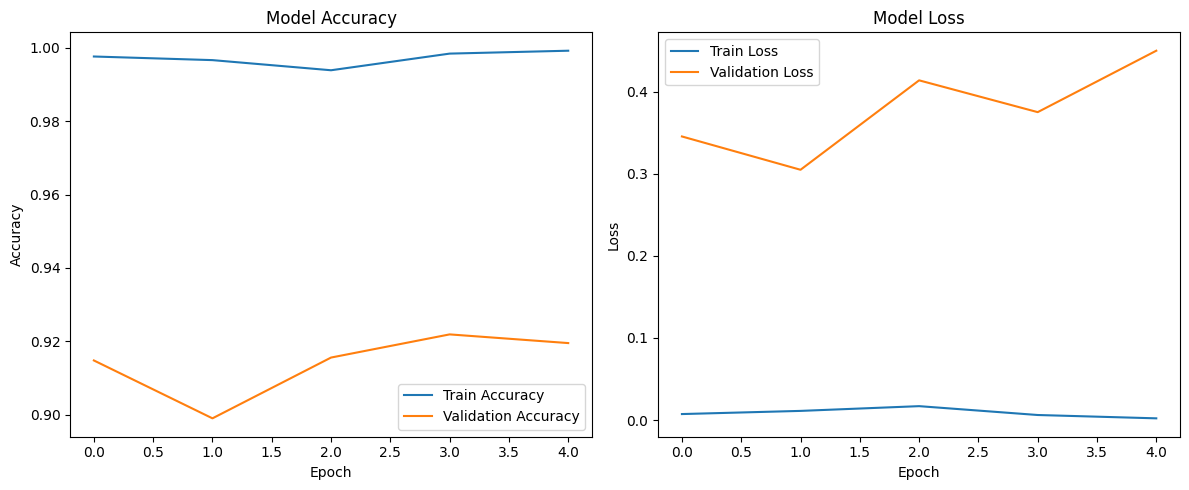

In [19]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [22]:

y_pred_prob = model.predict(X_test_seq)
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()


40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step


<ipython-input-23-798107417>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=predicted_labels, y=values, palette="Set2")


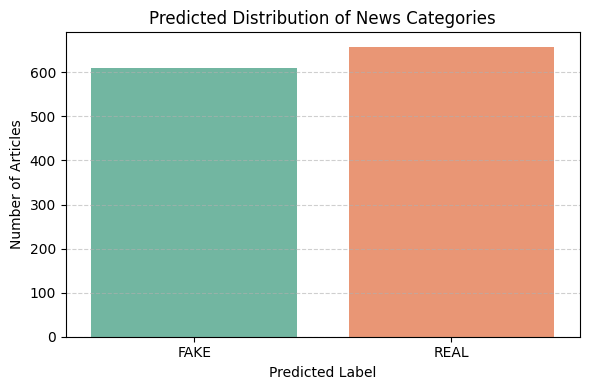

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


unique, counts = np.unique(y_pred, return_counts=True)
label_map = {0: "FAKE", 1: "REAL"}
predicted_labels = [label_map[i] for i in unique]
values = list(counts)


plt.figure(figsize=(6, 4))
sns.barplot(x=predicted_labels, y=values, palette="Set2")
plt.title("Predicted Distribution of News Categories")
plt.xlabel("Predicted Label")
plt.ylabel("Number of Articles")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


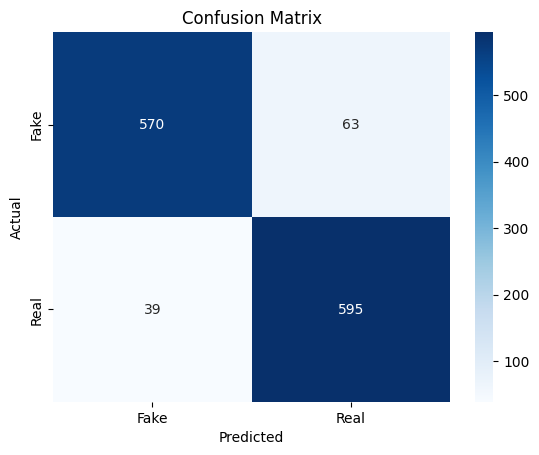

In [25]:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix



y_true = ['Fake'] * 633 + ['Real'] * 634
y_pred = ['Fake'] * 570 + ['Real'] * 63 + ['Fake'] * 39 + ['Real'] * 595


accuracy = accuracy_score(y_true, y_pred)


precision = precision_score(y_true, y_pred, pos_label='Real')
recall = recall_score(y_true, y_pred, pos_label='Real')
f1 = f1_score(y_true, y_pred, pos_label='Real')

print(f" Accuracy:  {accuracy:.4f}")
print(f" Precision: {precision:.4f}")
print(f" Recall:    {recall:.4f}")
print(f" F1-score:  {f1:.4f}")


 Accuracy:  0.9195
 Precision: 0.9043
 Recall:    0.9385
 F1-score:  0.9211
